# ANÁLISIS DE CALIDAD DE DATOS - SISMEPRE (Impuesto Predial Municipalidades)

---

## Contexto del Proyecto

### Descripción del Problema
El **Ministerio de Economía y Finanzas (MEF)**, a través del sistema **SISMEPRE**,
registra el presupuesto y ejecución del impuesto predial de las municipalidades
peruanas. Al consolidar los datos, se detectan inconsistencias en los registros
de respuestas, valores faltantes en campos clave, y formatos irregulares que
impiden analizar correctamente el cumplimiento de metas de recaudación predial
por municipalidad.

### Objetivo Analítico
Evaluar y mejorar la calidad de los datos del SISMEPRE para:
- Identificar municipalidades con registros incompletos o inconsistentes
- Verificar la integridad de los identificadores SEC_EJEC y ANO_APLICACION
- Detectar respuestas duplicadas o fuera de rango esperado
- Preparar el dataset limpio para el JOIN con SIAF y RENAMU en Silver

### Impacto de la Mala Calidad de Datos
- **Financiero**: Registros de recaudación predial incorrectos distorsionan
el análisis de cumplimiento de metas por municipalidad
- **Operativo**: Duplicados o respuestas inválidas generan conteos incorrectos
de municipalidades que reportaron su impuesto predial
- **Estratégico**: Decisiones de política tributaria municipal basadas en datos
incompletos pueden beneficiar o perjudicar municipios incorrectamente

---

## Dimensiones de Calidad a Evaluar

En este caso trabajaremos con:

1. **Completitud**: ¿Todos los registros tienen SEC_EJEC, ANO_APLICACION
y RESPUESTA_TEXTO completos?
2. **Exactitud**: ¿Los valores de RESPUESTA_DECIMAL y RESPUESTA_ENTERO
son correctos y coherentes?
3. **Consistencia**: ¿Los campos ESTADO, CLASIFICACION y PERIODO son
coherentes entre sí?
4. **Integridad**: ¿El SEC_EJEC de cada registro existe como municipalidad
válida en el SIAF?
5. **Razonabilidad**: ¿Los valores de RESPUESTA_DECIMAL están dentro de
rangos esperados para el impuesto predial?
6. **Oportunidad**: ¿Los datos cubren el período esperado según ANO_APLICACION
y ANO_ESTADISTICA?
7. **Unicidad**: ¿Existen registros duplicados por SEC_EJEC, PREGUNTA_ID
y ANO_APLICACION?
8. **Validez**: ¿Los valores de ESTADO y CLASIFICACION corresponden a los
códigos válidos del sistema SISMEPRE?

---

In [1]:
# Instalación de librerías necesarias
# !pip install pandas numpy matplotlib seaborn -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Configuración de visualización
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
%matplotlib inline


## Carga de Data


In [2]:
df = pd.read_csv('SISMEPRE_CAPA_SILVER.csv', encoding='latin-1')
print(f"✅ Dataset SISMEPRE cargado correctamente")

✅ Dataset SISMEPRE cargado correctamente


In [3]:
# Vista previa del dataset
df.head(10)

,SEC_EJEC,ANO_APLICACION,USUARIO_CREACION_FECHA,ESTADO,USUARIO_ENVIO_ID,USUARIO_FECHA_ENVIO,CORREO,ORIGEN_INFORMACION,CLASIFICACION,PERIODO,...,ANO_ESTADISTICA_DESC,SEC_EJEC_1,FORMULARIO_ID_1,PREGUNTA_ID,RESPUESTA_ID,RESPUESTA_TEXTO,RESPUESTA_DECIMAL,RESPUESTA_ENTERO,RESPUESTA_FECHA,ESTADO_REGISTRO_1
0,301003,2022,2022-01-25 18:20:51,A,0,,,1,A,1,...,2021,301071,5,86,75,0,0.0,0,,A
1,301046,2022,2022-01-25 18:20:52,A,0,,,1,A,1,...,2021,301071,5,86,75,0,0.0,0,,A
2,301052,2022,2022-01-25 18:20:52,A,0,,,1,A,1,...,2021,301071,5,86,75,0,0.0,0,,A
3,301090,2022,2022-01-25 18:20:52,A,0,,,1,A,1,...,2021,301071,5,86,75,0,0.0,0,,A
4,301098,2022,2022-01-25 18:20:52,A,0,,,1,A,1,...,2021,301071,5,86,75,0,0.0,0,,A
5,301108,2022,2022-01-25 18:20:52,A,0,,,1,A,1,...,2021,301071,5,86,75,0,0.0,0,,A
6,301118,2022,2022-01-25 18:20:52,A,0,,,1,A,1,...,2021,301071,5,86,75,0,0.0,0,,A
7,301127,2022,2022-01-25 18:20:52,A,0,,,1,A,1,...,2021,301071,5,86,75,0,0.0,0,,A
8,301154,2022,2022-01-25 18:20:52,A,0,,,1,A,1,...,2021,301071,5,86,75,0,0.0,0,,A
9,301189,2022,2022-01-25 18:20:52,A,0,,,1,A,1,...,2021,301071,5,86,75,0,0.0,0,,A


In [4]:
# Información general
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 27 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   SEC_EJEC                   100000 non-null  int64  
 1   ANO_APLICACION             100000 non-null  int64  
 2   USUARIO_CREACION_FECHA     100000 non-null  str    
 3   ESTADO                     100000 non-null  str    
 4   USUARIO_ENVIO_ID           100000 non-null  int64  
 5   USUARIO_FECHA_ENVIO        100000 non-null  str    
 6   CORREO                     100000 non-null  str    
 7   ORIGEN_INFORMACION         100000 non-null  int64  
 8   CLASIFICACION              100000 non-null  str    
 9   PERIODO                    100000 non-null  int64  
 10  TIPO_META                  100000 non-null  int64  
 11  IND_RESOL_ALCAL_ADJUNTO    100000 non-null  str    
 12  FECHA_RESOL_ALCAL_ADJUNTO  100000 non-null  str    
 13  FORMULARIO_ID              100000 non-nul

---

# FASE 1: Exploración Inicial y Diagnóstico de Calidad

Antes de limpiar datos, es fundamental **entender** qué problemas existen.
Esta es la fase de "Comprensión de Datos" de CRISP-DM aplicada al dataset
SISMEPRE de impuesto predial de municipalidades peruanas.

## Análisis Descriptivo Básico

In [5]:
# Estadísticas descriptivas
df.describe()

,SEC_EJEC,ANO_APLICACION,USUARIO_ENVIO_ID,ORIGEN_INFORMACION,PERIODO,TIPO_META,FORMULARIO_ID,ANO_ESTADISTICA,MES_ESTADISTICA,ANO_ESTADISTICA_DESC,SEC_EJEC_1,FORMULARIO_ID_1,PREGUNTA_ID,RESPUESTA_ID,RESPUESTA_DECIMAL,RESPUESTA_ENTERO
count,100000.00000,100000.0,100000.0,100000.0,100000.0,100000.0,100000.0,100000.0,100000.0,100000.0,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,301016.87714,2022.0,0.0,1.0,1.0,2.0,8.0,2021.0,13.0,2021.0,300908.006250,1.844000,50.596500,39.415000,0.050235,1.508750
std,586.05705,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,464.074789,1.296604,25.515715,22.188233,0.768934,18.416279
min,300001.00000,2022.0,0.0,1.0,1.0,2.0,8.0,2021.0,13.0,2021.0,300216.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,300414.00000,2022.0,0.0,1.0,1.0,2.0,8.0,2021.0,13.0,2021.0,300335.000000,1.000000,27.000000,20.000000,0.000000,0.000000
50%,301137.00000,2022.0,0.0,1.0,1.0,2.0,8.0,2021.0,13.0,2021.0,301071.000000,1.000000,51.000000,40.000000,0.000000,0.000000
75%,301500.00000,2022.0,0.0,1.0,1.0,2.0,8.0,2021.0,13.0,2021.0,301413.000000,2.000000,74.000000,59.000000,0.000000,0.000000
max,301886.00000,2022.0,0.0,1.0,1.0,2.0,8.0,2021.0,13.0,2021.0,301413.000000,5.000000,91.000000,75.000000,11.820000,279.000000


In [6]:
# Exploración inicial del dataset SISMEPRE
df[['ANO_APLICACION', 'RESPUESTA_DECIMAL',
    'RESPUESTA_ENTERO', 'PREGUNTA_ID',
    'RESPUESTA_ID']].describe().round(2)

,ANO_APLICACION,RESPUESTA_DECIMAL,RESPUESTA_ENTERO,PREGUNTA_ID,RESPUESTA_ID
count,100000.0,100000.00,100000.00,100000.00,100000.00
mean,2022.0,0.05,1.51,50.60,39.42
std,0.0,0.77,18.42,25.52,22.19
min,2022.0,0.00,0.00,1.00,1.00
25%,2022.0,0.00,0.00,27.00,20.00
50%,2022.0,0.00,0.00,51.00,40.00
75%,2022.0,0.00,0.00,74.00,59.00
max,2022.0,11.82,279.00,91.00,75.00


### Interpretación Inicial

**Observaciones clave del dataset SISMEPRE:**
- `RESPUESTA_DECIMAL` y `RESPUESTA_ENTERO` pueden presentar valores en cero
  o nulos, lo que debe verificarse según el tipo de pregunta registrada
- `ANO_APLICACION` debe estar en el rango esperado del proyecto
- `SEC_EJEC` es el identificador clave de cada municipalidad — no puede
  estar vacío ni fuera de rango
- `ESTADO` y `CLASIFICACION` deben tener solo valores permitidos por
  el sistema SISMEPRE

Estos son **indicadores claros** de problemas de calidad que guiarán
las correcciones en las siguientes fases.

## Diagnóstico por Dimensión de Calidad

In [10]:
# ============================================
# 1. COMPLETITUD
# ============================================
print("\nCOMPLETITUD - Análisis de Valores Faltantes SISMEPRE")

missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({
    'Valores Faltantes': missing,
    'Porcentaje': missing_pct
})
missing_df = missing_df[missing_df['Valores Faltantes'] > 0].sort_values('Valores Faltantes', ascending=False)

if len(missing_df) > 0:
    print(missing_df)
    print(f"\nTotal de campos con datos faltantes: {len(missing_df)}")
else:
    print("No se encontraron valores faltantes")


COMPLETITUD - Análisis de Valores Faltantes SISMEPRE
No se encontraron valores faltantes


In [11]:
# ============================================
# 2. EXACTITUD
# ============================================
print("\n\nEXACTITUD - Valores Incorrectos")

# Respuestas decimales negativas
respuesta_decimal_negativa = df[df['RESPUESTA_DECIMAL'] < 0]
print(f"- RESPUESTA_DECIMAL negativa: {len(respuesta_decimal_negativa)}")

# Respuestas enteras negativas
respuesta_entero_negativa = df[df['RESPUESTA_ENTERO'] < 0]
print(f"- RESPUESTA_ENTERO negativa: {len(respuesta_entero_negativa)}")

# PREGUNTA_ID o RESPUESTA_ID en cero
pregunta_cero = df[df['PREGUNTA_ID'] <= 0]
print(f"- PREGUNTA_ID <= 0: {len(pregunta_cero)}")



EXACTITUD - Valores Incorrectos
- RESPUESTA_DECIMAL negativa: 0
- RESPUESTA_ENTERO negativa: 0
- PREGUNTA_ID <= 0: 0


In [12]:
# ============================================
# 3. CONSISTENCIA
# ============================================
print("\n\nCONSISTENCIA - Incoherencias entre Campos")

# ESTADO debe ser consistente con ESTADO_REGISTRO
estados_inconsistentes = df[df['ESTADO'] != df['ESTADO_REGISTRO']]
print(f"ESTADO vs ESTADO_REGISTRO inconsistentes: {len(estados_inconsistentes)}")

# SEC_EJEC debe coincidir con SEC_EJEC_1
sec_ejec_inconsistente = df[df['SEC_EJEC'] != df['SEC_EJEC_1']]
print(f"SEC_EJEC vs SEC_EJEC_1 inconsistentes: {len(sec_ejec_inconsistente)}")

# FORMULARIO_ID debe coincidir con FORMULARIO_ID_1
formulario_inconsistente = df[df['FORMULARIO_ID'] != df['FORMULARIO_ID_1']]
print(f"FORMULARIO_ID vs FORMULARIO_ID_1 inconsistentes: {len(formulario_inconsistente)}")



CONSISTENCIA - Incoherencias entre Campos
ESTADO vs ESTADO_REGISTRO inconsistentes: 0
SEC_EJEC vs SEC_EJEC_1 inconsistentes: 99915
FORMULARIO_ID vs FORMULARIO_ID_1 inconsistentes: 100000


In [13]:
# ============================================
# 4. INTEGRIDAD
# ============================================
print("\n\nINTEGRIDAD - Relaciones entre Datos")

# SEC_EJEC fuera de rango esperado
sec_ejec_invalidos = df[(df['SEC_EJEC'] <= 0)]
print(f"SEC_EJEC fuera de rango [>0]: {len(sec_ejec_invalidos)}")

# ANO_APLICACION fuera de rango esperado
ano_invalidos = df[(df['ANO_APLICACION'] < 2010) | (df['ANO_APLICACION'] > 2026)]
print(f"ANO_APLICACION fuera de rango [2010-2026]: {len(ano_invalidos)}")



INTEGRIDAD - Relaciones entre Datos
SEC_EJEC fuera de rango [>0]: 0
ANO_APLICACION fuera de rango [2010-2026]: 0


In [14]:
# ============================================
# 5. RAZONABILIDAD
# ============================================
print("\n\nRAZONABILIDAD - Valores Fuera de Rangos Esperados")

# Respuestas decimales extremas
respuesta_decimal_extrema = df[df['RESPUESTA_DECIMAL'] > df['RESPUESTA_DECIMAL'].quantile(0.99)]
print(f"RESPUESTA_DECIMAL > percentil 99: {len(respuesta_decimal_extrema)}")

# Respuestas enteras extremas
respuesta_entero_extrema = df[df['RESPUESTA_ENTERO'] > df['RESPUESTA_ENTERO'].quantile(0.99)]
print(f"RESPUESTA_ENTERO > percentil 99: {len(respuesta_entero_extrema)}")



RAZONABILIDAD - Valores Fuera de Rangos Esperados
RESPUESTA_DECIMAL > percentil 99: 425
RESPUESTA_ENTERO > percentil 99: 850


In [15]:
# ============================================
# 6. OPORTUNIDAD
# ============================================
print("\n\nOPORTUNIDAD - Actualidad de los Datos")

ano_actual = datetime.now().year
anos_futuros = df[df['ANO_APLICACION'] > ano_actual]
anos_antiguos = df[df['ANO_APLICACION'] < 2010]

print(f"- ANO_APLICACION en el futuro: {len(anos_futuros)}")
print(f"- ANO_APLICACION antes de 2010: {len(anos_antiguos)}")



OPORTUNIDAD - Actualidad de los Datos
- ANO_APLICACION en el futuro: 0
- ANO_APLICACION antes de 2010: 0


In [16]:
# ============================================
# 7. UNICIDAD
# ============================================
print("\n\nUNICIDAD - Duplicados")

# Duplicados exactos
cols_duplicados = [c for c in df.columns]
duplicados_exactos = df[df.duplicated(subset=cols_duplicados, keep=False)]
print(f"- Registros duplicados (exactos): {len(duplicados_exactos)}")

# Duplicados parciales
cols_key = ['SEC_EJEC', 'ANO_APLICACION', 'PREGUNTA_ID']
duplicados_parciales = df[df.duplicated(subset=cols_key, keep=False)]
print(f"- Duplicados parciales (mismo SEC_EJEC, ANO_APLICACION, PREGUNTA_ID): {len(duplicados_parciales)}")



UNICIDAD - Duplicados
- Registros duplicados (exactos): 0
- Duplicados parciales (mismo SEC_EJEC, ANO_APLICACION, PREGUNTA_ID): 100000


In [17]:
# ============================================
# 8. VALIDEZ
# ============================================
print("\n\nVALIDEZ - Formatos Incorrectos")

# ESTADO debe ser A (activo) o I (inactivo)
estados_validos = ['A', 'I']
estados_invalidos = df[~df['ESTADO'].isin(estados_validos)]
print(f"- ESTADO con valor inválido: {len(estados_invalidos)}")

# CLASIFICACION debe ser A o B
clasificacion_valida = ['A', 'B']
clasificacion_invalida = df[~df['CLASIFICACION'].isin(clasificacion_valida)]
print(f"- CLASIFICACION con valor inválido: {len(clasificacion_invalida)}")



VALIDEZ - Formatos Incorrectos
- ESTADO con valor inválido: 0
- CLASIFICACION con valor inválido: 58515


In [18]:
print("RESUMEN DEL DIAGNÓSTICO")
print(f"- Total de registros: {len(df)}")
print(f"- Total de problemas detectados: {len(missing_df) + len(respuesta_decimal_negativa) + len(respuesta_entero_negativa) + len(estados_inconsistentes) + len(duplicados_exactos) + len(estados_invalidos)}")

RESUMEN DEL DIAGNÓSTICO
- Total de registros: 100000
- Total de problemas detectados: 0


## Visualización de Problemas de Calidad

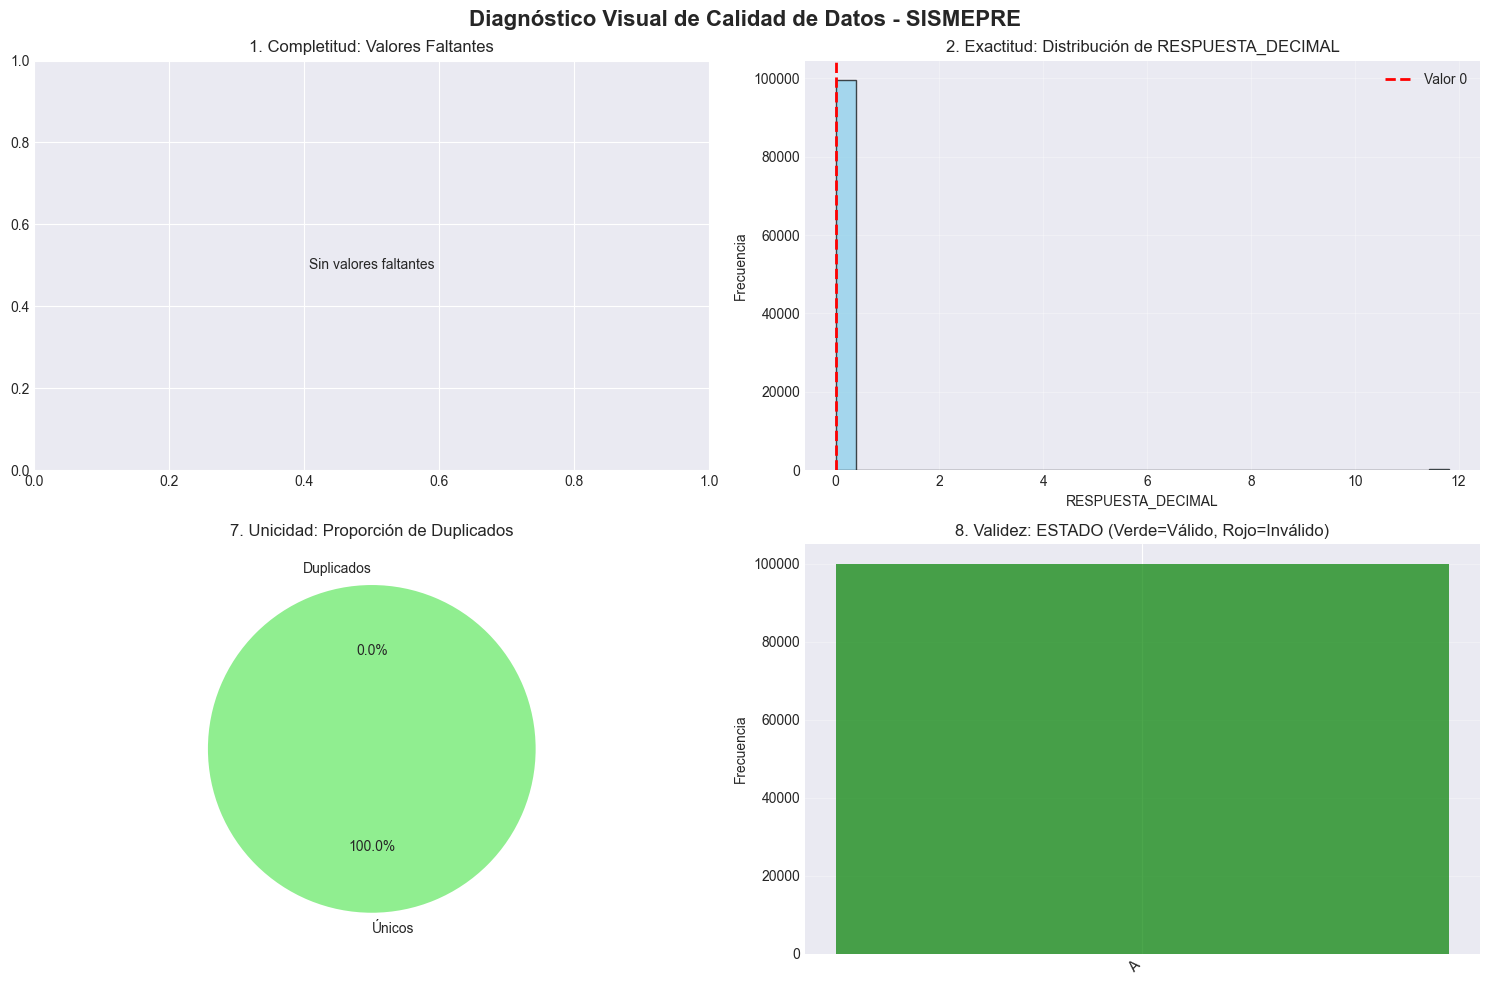

In [19]:
# Crear visualizaciones de problemas
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Diagnóstico Visual de Calidad de Datos - SISMEPRE', fontsize=16, fontweight='bold')

# 1. Valores faltantes
if len(missing_df) > 0:
    axes[0, 0].barh(missing_df.index, missing_df['Valores Faltantes'], color='coral')
    axes[0, 0].set_xlabel('Cantidad')
    axes[0, 0].set_title('1. Completitud: Valores Faltantes')
    axes[0, 0].grid(axis='x', alpha=0.3)
else:
    axes[0, 0].text(0.5, 0.5, 'Sin valores faltantes', ha='center', va='center')
    axes[0, 0].set_title('1. Completitud: Valores Faltantes')

# 2. Distribución de RESPUESTA_DECIMAL
axes[0, 1].hist(df['RESPUESTA_DECIMAL'].dropna(), bins=30, color='skyblue', edgecolor='black', alpha=0.7)
axes[0, 1].axvline(0, color='red', linestyle='--', linewidth=2, label='Valor 0')
axes[0, 1].set_xlabel('RESPUESTA_DECIMAL')
axes[0, 1].set_ylabel('Frecuencia')
axes[0, 1].set_title('2. Exactitud: Distribución de RESPUESTA_DECIMAL')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# 3. Duplicados
duplicados_summary = pd.Series({
    'Únicos': len(df) - len(duplicados_exactos),
    'Duplicados': len(duplicados_exactos)
})
axes[1, 0].pie(duplicados_summary, labels=duplicados_summary.index, autopct='%1.1f%%',
               colors=['lightgreen', 'salmon'], startangle=90)
axes[1, 0].set_title('7. Unicidad: Proporción de Duplicados')

# 4. Validez - ESTADO
estado_counts = df['ESTADO'].value_counts()
colores = ['green' if e in estados_validos else 'red' for e in estado_counts.index]
axes[1, 1].bar(range(len(estado_counts)), estado_counts.values, color=colores, alpha=0.7)
axes[1, 1].set_xticks(range(len(estado_counts)))
axes[1, 1].set_xticklabels(estado_counts.index, rotation=45, ha='right')
axes[1, 1].set_ylabel('Frecuencia')
axes[1, 1].set_title('8. Validez: ESTADO (Verde=Válido, Rojo=Inválido)')
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### Interpretación de las Visualizaciones

**Gráfico 1 - Completitud:**
- Muestra las columnas del SISMEPRE con valores faltantes
- Columnas como RESPUESTA_TEXTO o RESPUESTA_FECHA pueden tener
  nulos válidos dependiendo del tipo de pregunta registrada

**Gráfico 2 - Exactitud:**
- La distribución de RESPUESTA_DECIMAL muestra la concentración
  de valores reportados por las municipalidades
- Valores negativos son imposibles para montos de impuesto predial
  y deben corregirse antes de Silver

**Gráfico 3 - Unicidad:**
- Si hay duplicados exactos, los conteos de municipalidades que
  reportaron su predial quedarían inflados artificialmente
- Un mismo SEC_EJEC con la misma PREGUNTA_ID duplicada distorsiona
  el análisis de cumplimiento de metas

**Gráfico 4 - Validez:**
- Las barras verdes corresponden a valores de ESTADO válidos (A/I)
- Las barras rojas indican códigos inválidos que romperían
  la integridad del dataset al integrarlo con SIAF y RENAMU

---

# SOLUCIÓN NIVEL SIMPLE - SISMEPRE

## Objetivo
Aplicar técnicas básicas de limpieza sobre el dataset SISMEPRE
de impuesto predial de municipalidades peruanas:
- Eliminar registros con valores nulos
- Eliminar duplicados exactos
- Filtrar valores obviamente incorrectos

### Limitaciones de este enfoque:
- Pérdida significativa de datos
- No trata problemas sutiles
- No aprovecha información recuperable

In [20]:
# Crear copia para solución simple
df_simple = df.copy()

print(f"Registros iniciales: {len(df_simple)}")
print("\nPASOS DE LIMPIEZA:\n")

# Paso 1: Eliminar filas con valores nulos
antes_nulos = len(df_simple)
df_simple = df_simple.dropna()
despues_nulos = len(df_simple)
print(f"1. Eliminación de nulos: {antes_nulos - despues_nulos} registros eliminados")

# Paso 2: Eliminar duplicados exactos
antes_dup = len(df_simple)
df_simple = df_simple.drop_duplicates(subset=cols_duplicados, keep='first')
despues_dup = len(df_simple)
print(f"2. Eliminación de duplicados exactos: {antes_dup - despues_dup} registros eliminados")

# Paso 3: Filtrar RESPUESTA_DECIMAL y RESPUESTA_ENTERO negativos
antes_neg = len(df_simple)
df_simple = df_simple[
    (df_simple['RESPUESTA_DECIMAL'] >= 0) &
    (df_simple['RESPUESTA_ENTERO']  >= 0)
]
despues_neg = len(df_simple)
print(f"3. Filtrado de respuestas negativas: {antes_neg - despues_neg} registros eliminados")

# Paso 4: Filtrar ANO_APLICACION fuera de rango
antes_ano = len(df_simple)
df_simple = df_simple[
    (df_simple['ANO_APLICACION'] >= 2010) &
    (df_simple['ANO_APLICACION'] <= 2026)
]
despues_ano = len(df_simple)
print(f"4. Filtrado de años fuera de rango: {antes_ano - despues_ano} registros eliminados")

# Paso 5: Estandarizar ESTADO
df_simple['ESTADO'] = df_simple['ESTADO'].str.upper().str.strip()
print(f"5. Estandarización de ESTADO: Aplicada")

print(f"\n- Registros finales: {len(df_simple)}")
print(f"- Pérdida total: {len(df) - len(df_simple)} registros ({((len(df) - len(df_simple))/len(df)*100):.1f}%)")

Registros iniciales: 100000

PASOS DE LIMPIEZA:

1. Eliminación de nulos: 0 registros eliminados
2. Eliminación de duplicados exactos: 0 registros eliminados
3. Filtrado de respuestas negativas: 0 registros eliminados
4. Filtrado de años fuera de rango: 0 registros eliminados
5. Estandarización de ESTADO: Aplicada

- Registros finales: 100000
- Pérdida total: 0 registros (0.0%)


In [21]:
# Verificación post-limpieza
print("\nVERIFICACIÓN POST-LIMPIEZA (SOLUCIÓN SIMPLE)\n")
print(f"- Valores nulos: {df_simple.isnull().sum().sum()}")
print(f"- Duplicados exactos: {df_simple.duplicated(subset=cols_duplicados).sum()}")
print(f"- RESPUESTA_DECIMAL negativa: {len(df_simple[df_simple['RESPUESTA_DECIMAL'] < 0])}")
print(f"- RESPUESTA_ENTERO negativa: {len(df_simple[df_simple['RESPUESTA_ENTERO'] < 0])}")
print(f"- ANO_APLICACION fuera de rango: {len(df_simple[(df_simple['ANO_APLICACION'] < 2010) | (df_simple['ANO_APLICACION'] > 2026)])}")


VERIFICACIÓN POST-LIMPIEZA (SOLUCIÓN SIMPLE)

- Valores nulos: 0
- Duplicados exactos: 0
- RESPUESTA_DECIMAL negativa: 0
- RESPUESTA_ENTERO negativa: 0
- ANO_APLICACION fuera de rango: 0


In [22]:
df_simple.to_parquet("sismepre_silver_simple.parquet", index=False)
print(f"✅ Archivo guardado: sismepre_silver_simple.parquet")
print(f"   Registros: {len(df_simple):,}")
print(f"   Columnas : {len(df_simple.columns)}")

✅ Archivo guardado: sismepre_silver_simple.parquet
   Registros: 100,000
   Columnas : 27


### Conclusiones de la Solución Simple

**Ventajas:**
- Fácil de implementar
- Elimina errores evidentes
- No requiere conocimiento avanzado

**Desventajas:**
- Pérdida significativa de datos
- No recupera información valiosa
- No trata problemas sutiles (inconsistencias, integridad)
- Puede introducir sesgos al eliminar datos sistemáticamente